In [75]:
from pathlib import Path
import json
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\EnnoSmart")
PROJECTS_DIR = BASE_DIR / "projects"

PROJECT_IDS = [f"projet_{i}_" for i in range(1, 33)]

LABELS = [
    "VERROU_TECH",
    "METHODE_RD",
    "TECHNOLOGIE_RD",
    "EQUIPEMENT_RD",
    "COMPOSANT_TECHNIQUE",
    "MATERIAU_SPECIFIQUE",
    "DOMAINE_RD",
    "ORGANISME",
    "PERSONNE",
    "RESULTAT_RD",
    "OBJECTIF_RD",
    "DATE_PERIODE",
    "MONTANT_CIR",
    "ETP",
    "LIEU",
    "JALON",
]

CORE_LABELS = {
    "VERROU_TECH",
    "METHODE_RD",
    "TECHNOLOGIE_RD",
    "EQUIPEMENT_RD",
    "COMPOSANT_TECHNIQUE",
    "MATERIAU_SPECIFIQUE",
    "DOMAINE_RD",
    "RESULTAT_RD",
    "OBJECTIF_RD",
}

SECONDARY_LABELS = set(LABELS) - CORE_LABELS

print("Projects:", len(PROJECT_IDS))
print(PROJECT_IDS)

Projects: 32
['projet_1_', 'projet_2_', 'projet_3_', 'projet_4_', 'projet_5_', 'projet_6_', 'projet_7_', 'projet_8_', 'projet_9_', 'projet_10_', 'projet_11_', 'projet_12_', 'projet_13_', 'projet_14_', 'projet_15_', 'projet_16_', 'projet_17_', 'projet_18_', 'projet_19_', 'projet_20_', 'projet_21_', 'projet_22_', 'projet_23_', 'projet_24_', 'projet_25_', 'projet_26_', 'projet_27_', 'projet_28_', 'projet_29_', 'projet_30_', 'projet_31_', 'projet_32_']


In [76]:
def find_annotation_file(project_id):
    ann_dir = PROJECTS_DIR / project_id / "annotations"
    
    candidates = [
        ann_dir / "ner_candidates_clean_balanced.json",
        ann_dir / "ner_candidates_clean.json",
        ann_dir / "ner_candidates.json",
    ]
    
    for path in candidates:
        if path.exists():
            return path
    
    return None


files_info = []

for project_id in PROJECT_IDS:
    path = find_annotation_file(project_id)
    files_info.append({
        "project_id": project_id,
        "file_found": path is not None,
        "file_name": path.name if path else None,
        "file_path": str(path) if path else None,
    })

df_files = pd.DataFrame(files_info)
df_files

,project_id,file_found,file_name,file_path
0,projet_1_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_1_\annotations\ne...
1,projet_2_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_2_\annotations\ne...
2,projet_3_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_3_\annotations\ne...
3,projet_4_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_4_\annotations\ne...
4,projet_5_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_5_\annotations\ne...
5,projet_6_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_6_\annotations\ne...
6,projet_7_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_7_\annotations\ne...
7,projet_8_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_8_\annotations\ne...
8,projet_9_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_9_\annotations\ne...
9,projet_10_,True,ner_candidates_clean.json,C:\EnnoSmart\projects\projet_10_\annotations\n...


In [77]:
all_items = []
load_stats = []

for project_id in PROJECT_IDS:
    path = find_annotation_file(project_id)
    
    if path is None:
        load_stats.append({
            "project_id": project_id,
            "status": "missing",
            "chunks": 0,
            "entities": 0,
            "file": None,
        })
        continue
    
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    nb_chunks = len(data)
    nb_entities = sum(len(item.get("entities", [])) for item in data)
    
    load_stats.append({
        "project_id": project_id,
        "status": "loaded",
        "chunks": nb_chunks,
        "entities": nb_entities,
        "file": path.name,
    })
    
    for item in data:
        item_copy = dict(item)
        item_copy["project_id"] = project_id
        item_copy["_source_annotation_file"] = path.name
        all_items.append(item_copy)

df_load = pd.DataFrame(load_stats)
df_load

,project_id,status,chunks,entities,file
0,projet_1_,loaded,333,1151,ner_candidates_clean.json
1,projet_2_,loaded,324,967,ner_candidates_clean.json
2,projet_3_,loaded,1751,3807,ner_candidates_clean.json
3,projet_4_,loaded,1245,4021,ner_candidates_clean.json
4,projet_5_,loaded,47,155,ner_candidates_clean.json
5,projet_6_,loaded,92,307,ner_candidates_clean.json
6,projet_7_,loaded,324,730,ner_candidates_clean.json
7,projet_8_,loaded,35,80,ner_candidates_clean.json
8,projet_9_,loaded,259,774,ner_candidates_clean.json
9,projet_10_,loaded,214,440,ner_candidates_clean.json


In [78]:
total_chunks = len(all_items)
total_entities = sum(len(item.get("entities", [])) for item in all_items)
chunks_with_entities = sum(1 for item in all_items if len(item.get("entities", [])) > 0)
chunks_without_entities = total_chunks - chunks_with_entities

summary = {
    "total_projects": len(PROJECT_IDS),
    "total_chunks": total_chunks,
    "chunks_with_entities": chunks_with_entities,
    "chunks_without_entities": chunks_without_entities,
    "total_entities": total_entities,
}

summary

{'total_projects': 32,
 'total_chunks': 7426,
 'chunks_with_entities': 4834,
 'chunks_without_entities': 2592,
 'total_entities': 21717}

In [79]:
rows = []

for item_idx, item in enumerate(all_items):
    project_id = item.get("project_id")
    text = item.get("text", "")
    
    for ent in item.get("entities", []):
        rows.append({
            "project_id": project_id,
            "annotation_id": item.get("annotation_id", ""),
            "source_file": item.get("source_file", ""),
            "chunk_index": item_idx,
            "label": ent.get("label", ""),
            "text": ent.get("text", ""),
            "start": ent.get("start", None),
            "end": ent.get("end", None),
            "score": ent.get("score", None),
            "status": ent.get("status", ""),
            "annotation_status": item.get("annotation_status", ""),
            "project_tax_type": item.get("project_tax_type", ""),
            "use_for_cir_training": item.get("use_for_cir_training", None),
        })

df_entities = pd.DataFrame(rows)

print("Nombre d'entités:", len(df_entities))
df_entities.head(20)

Nombre d'entités: 21717


,project_id,annotation_id,source_file,chunk_index,label,text,start,end,score,status,annotation_status,project_tax_type,use_for_cir_training
0,projet_1_,projet_1__chunk_000000_part_000,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,0,DATE_PERIODE,2024,948,952,0.5000,candidate,force_cleaned,,None
1,projet_1_,projet_1__chunk_000000_part_001,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,1,DATE_PERIODE,2024,624,628,0.5730,candidate,force_cleaned,,None
2,projet_1_,projet_1__chunk_000001_part_000,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,2,ORGANISME,Biologique Recherche,21,41,0.8856,rule_fixed,force_cleaned,,None
3,projet_1_,projet_1__chunk_000001_part_000,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,2,DATE_PERIODE,1982,57,61,0.8148,candidate,force_cleaned,,None
4,projet_1_,projet_1__chunk_000001_part_000,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,2,PERSONNE,Monsieur Yvan Allouche,118,140,0.9235,candidate,force_cleaned,,None
5,projet_1_,projet_1__chunk_000001_part_000,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,2,PERSONNE,Madame Josette Allouche,190,213,0.9520,candidate,force_cleaned,,None
6,projet_1_,projet_1__chunk_000001_part_000,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,2,DATE_PERIODE,2007,659,663,0.7710,candidate,force_cleaned,,None
7,projet_1_,projet_1__chunk_000001_part_000,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,2,PERSONNE,Rupert Schmid,704,717,0.9203,candidate,force_cleaned,,None
8,projet_1_,projet_1__chunk_000001_part_000,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,2,PERSONNE,Pierre-Louis Delapalme,731,753,0.9553,candidate,force_cleaned,,None
9,projet_1_,projet_1__chunk_000001_part_000,C:\EnnoSmart\projects\projet_1_\cir_final\BR _...,2,PERSONNE,Philippe Allouche,777,794,0.9523,candidate,force_cleaned,,None


In [80]:
df_label_counts = (
    df_entities["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

df_label_counts["ratio"] = df_label_counts["count"] / df_label_counts["count"].sum()
df_label_counts["type"] = df_label_counts["label"].apply(
    lambda x: "CORE" if x in CORE_LABELS else "SECONDARY"
)

df_label_counts

,label,count,ratio,type
0,DATE_PERIODE,4201,0.193443,SECONDARY
1,ORGANISME,2902,0.133628,SECONDARY
2,PERSONNE,2502,0.115209,SECONDARY
3,COMPOSANT_TECHNIQUE,2048,0.094304,CORE
4,METHODE_RD,1719,0.079155,CORE
5,MATERIAU_SPECIFIQUE,1513,0.069669,CORE
6,TECHNOLOGIE_RD,1491,0.068656,CORE
7,LIEU,1133,0.052171,SECONDARY
8,VERROU_TECH,1074,0.049454,CORE
9,DOMAINE_RD,912,0.041995,CORE


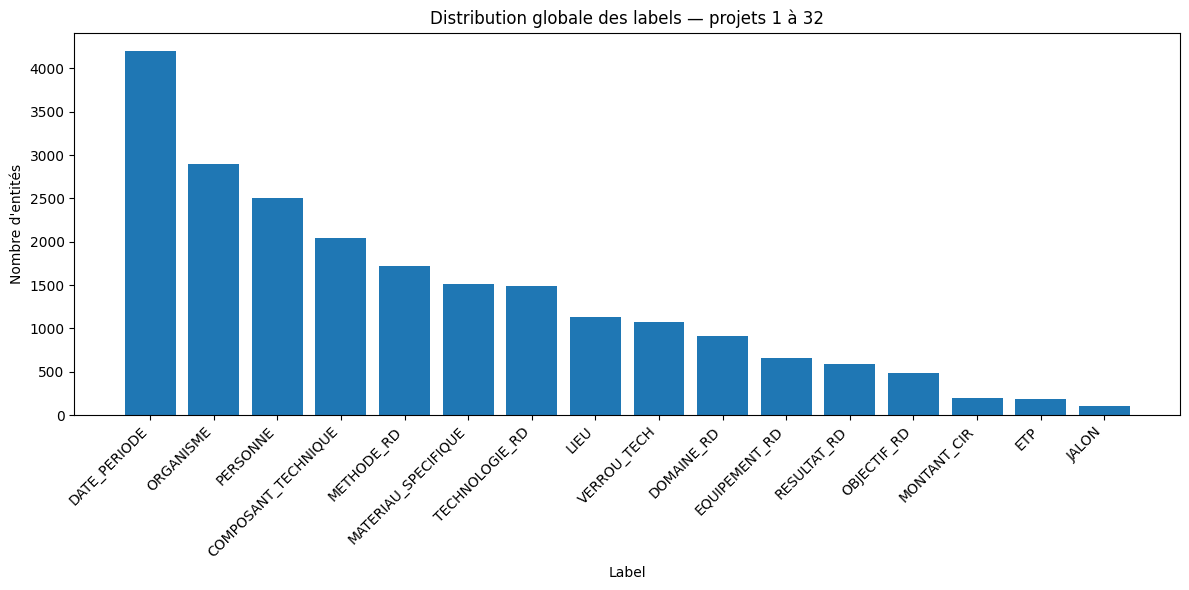

In [81]:
plt.figure(figsize=(12, 6))
plt.bar(df_label_counts["label"], df_label_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribution globale des labels — projets 1 à 32")
plt.xlabel("Label")
plt.ylabel("Nombre d'entités")
plt.tight_layout()
plt.show()

In [82]:
df_core_counts = df_label_counts[df_label_counts["label"].isin(CORE_LABELS)].copy()
df_core_counts = df_core_counts.sort_values("count", ascending=False)

df_core_counts

,label,count,ratio,type
3,COMPOSANT_TECHNIQUE,2048,0.094304,CORE
4,METHODE_RD,1719,0.079155,CORE
5,MATERIAU_SPECIFIQUE,1513,0.069669,CORE
6,TECHNOLOGIE_RD,1491,0.068656,CORE
8,VERROU_TECH,1074,0.049454,CORE
9,DOMAINE_RD,912,0.041995,CORE
10,EQUIPEMENT_RD,658,0.030299,CORE
11,RESULTAT_RD,594,0.027352,CORE
12,OBJECTIF_RD,485,0.022333,CORE


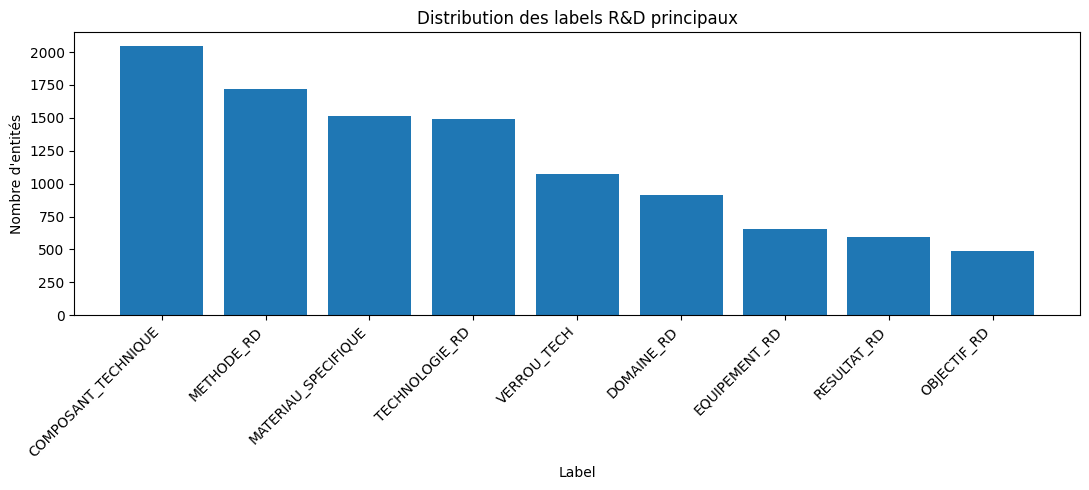

In [83]:
plt.figure(figsize=(11, 5))
plt.bar(df_core_counts["label"], df_core_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribution des labels R&D principaux")
plt.xlabel("Label")
plt.ylabel("Nombre d'entités")
plt.tight_layout()
plt.show()

In [84]:
df_project_counts = (
    df_entities
    .groupby("project_id")
    .size()
    .reset_index(name="entities")
)

df_project_chunks = (
    df_load[["project_id", "chunks"]]
    .copy()
)

df_project_summary = df_project_chunks.merge(df_project_counts, on="project_id", how="left")
df_project_summary["entities"] = df_project_summary["entities"].fillna(0).astype(int)
df_project_summary["entities_per_chunk"] = (
    df_project_summary["entities"] / df_project_summary["chunks"].replace(0, 1)
)

df_project_summary

,project_id,chunks,entities,entities_per_chunk
0,projet_1_,333,1151,3.456456
1,projet_2_,324,967,2.984568
2,projet_3_,1751,3807,2.174186
3,projet_4_,1245,4021,3.229719
4,projet_5_,47,155,3.297872
5,projet_6_,92,307,3.336957
6,projet_7_,324,730,2.253086
7,projet_8_,35,80,2.285714
8,projet_9_,259,774,2.988417
9,projet_10_,214,440,2.056075


In [85]:
total_entities = len(df_entities)

df_balance_check = df_label_counts.copy()
df_balance_check["percentage"] = (df_balance_check["count"] / total_entities * 100).round(2)

def balance_status(row):
    label = row["label"]
    count = row["count"]
    pct = row["percentage"]
    
    if label in CORE_LABELS:
        if count < 100:
            return "FAIBLE_CORE"
        if pct > 18:
            return "DOMINANT_CORE"
        return "OK_CORE"
    else:
        if pct > 10:
            return "DOMINANT_SECONDARY"
        return "SECONDARY"

df_balance_check["status_balance"] = df_balance_check.apply(balance_status, axis=1)
df_balance_check

,label,count,ratio,type,percentage,status_balance
0,DATE_PERIODE,4201,0.193443,SECONDARY,19.34,DOMINANT_SECONDARY
1,ORGANISME,2902,0.133628,SECONDARY,13.36,DOMINANT_SECONDARY
2,PERSONNE,2502,0.115209,SECONDARY,11.52,DOMINANT_SECONDARY
3,COMPOSANT_TECHNIQUE,2048,0.094304,CORE,9.43,OK_CORE
4,METHODE_RD,1719,0.079155,CORE,7.92,OK_CORE
5,MATERIAU_SPECIFIQUE,1513,0.069669,CORE,6.97,OK_CORE
6,TECHNOLOGIE_RD,1491,0.068656,CORE,6.87,OK_CORE
7,LIEU,1133,0.052171,SECONDARY,5.22,SECONDARY
8,VERROU_TECH,1074,0.049454,CORE,4.95,OK_CORE
9,DOMAINE_RD,912,0.041995,CORE,4.20,OK_CORE


In [86]:
CORE_LABELS = {
    "VERROU_TECH",
    "METHODE_RD",
    "TECHNOLOGIE_RD",
    "EQUIPEMENT_RD",
    "COMPOSANT_TECHNIQUE",
    "MATERIAU_SPECIFIQUE",
    "DOMAINE_RD",
    "RESULTAT_RD",
    "OBJECTIF_RD",
}

df_core_entities = df_entities[df_entities["label"].isin(CORE_LABELS)].copy()

df_core_label_counts = (
    df_core_entities["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

df_core_label_counts["ratio"] = df_core_label_counts["count"] / df_core_label_counts["count"].sum()

df_core_label_counts

,label,count,ratio
0,COMPOSANT_TECHNIQUE,2048,0.195159
1,METHODE_RD,1719,0.163808
2,MATERIAU_SPECIFIQUE,1513,0.144178
3,TECHNOLOGIE_RD,1491,0.142081
4,VERROU_TECH,1074,0.102344
5,DOMAINE_RD,912,0.086907
6,EQUIPEMENT_RD,658,0.062702
7,RESULTAT_RD,594,0.056604
8,OBJECTIF_RD,485,0.046217


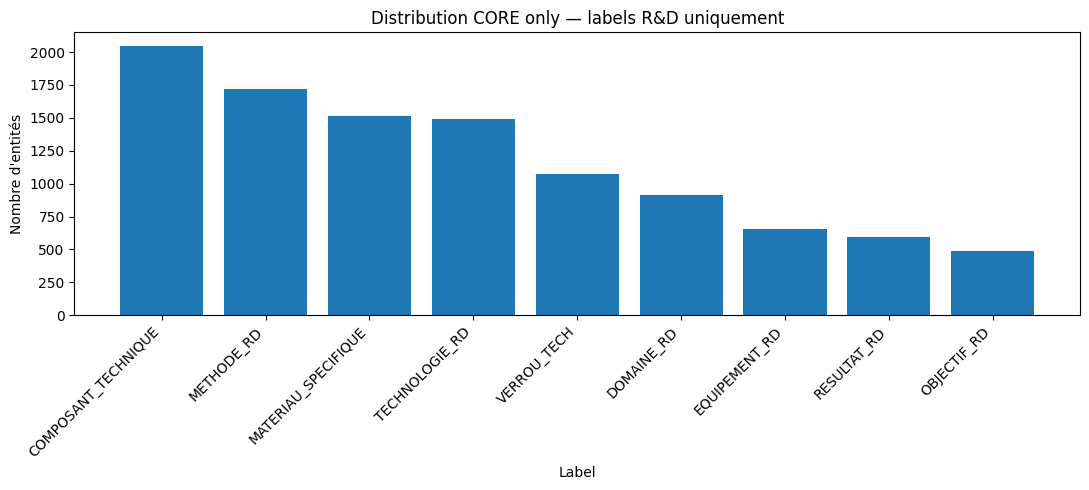

In [87]:
plt.figure(figsize=(11, 5))
plt.bar(df_core_label_counts["label"], df_core_label_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribution CORE only — labels R&D uniquement")
plt.xlabel("Label")
plt.ylabel("Nombre d'entités")
plt.tight_layout()
plt.show()

In [88]:
df_core_project_counts = (
    df_core_entities
    .groupby("project_id")
    .size()
    .reset_index(name="core_entities")
)

df_core_project_summary = df_project_summary.merge(
    df_core_project_counts,
    on="project_id",
    how="left"
)

df_core_project_summary["core_entities"] = df_core_project_summary["core_entities"].fillna(0).astype(int)
df_core_project_summary["core_entities_per_chunk"] = (
    df_core_project_summary["core_entities"] / df_core_project_summary["chunks"].replace(0, 1)
)

df_core_project_summary

,project_id,chunks,entities,entities_per_chunk,core_entities,core_entities_per_chunk
0,projet_1_,333,1151,3.456456,508,1.525526
1,projet_2_,324,967,2.984568,476,1.469136
2,projet_3_,1751,3807,2.174186,681,0.388921
3,projet_4_,1245,4021,3.229719,387,0.310843
4,projet_5_,47,155,3.297872,128,2.723404
5,projet_6_,92,307,3.336957,257,2.793478
6,projet_7_,324,730,2.253086,328,1.012346
7,projet_8_,35,80,2.285714,60,1.714286
8,projet_9_,259,774,2.988417,579,2.235521
9,projet_10_,214,440,2.056075,154,0.719626


In [89]:
df_core_project_label_matrix = (
    df_core_entities
    .pivot_table(
        index="project_id",
        columns="label",
        values="text",
        aggfunc="count",
        fill_value=0
    )
)

core_order = [
    "COMPOSANT_TECHNIQUE",
    "METHODE_RD",
    "MATERIAU_SPECIFIQUE",
    "TECHNOLOGIE_RD",
    "VERROU_TECH",
    "DOMAINE_RD",
    "EQUIPEMENT_RD",
    "RESULTAT_RD",
    "OBJECTIF_RD",
]

existing_core_order = [x for x in core_order if x in df_core_project_label_matrix.columns]
df_core_project_label_matrix = df_core_project_label_matrix[existing_core_order]

df_core_project_label_matrix

label,COMPOSANT_TECHNIQUE,METHODE_RD,MATERIAU_SPECIFIQUE,TECHNOLOGIE_RD,VERROU_TECH,DOMAINE_RD,EQUIPEMENT_RD,RESULTAT_RD,OBJECTIF_RD
project_id,,,,,,,,,
projet_10_,0,24,0,83,2,28,0,14,3
projet_11_,0,141,0,180,4,8,0,7,1
projet_12_,71,110,3,213,19,56,43,17,35
projet_13_,7,34,34,84,17,10,59,14,6
projet_14_,175,1,0,27,4,10,108,0,1
projet_15_,78,54,11,10,46,0,0,9,42
projet_16_,34,40,4,24,44,33,21,13,13
projet_17_,84,55,0,61,43,38,59,19,18
projet_19_,60,50,0,83,43,57,10,18,14


Total entités : 21717
CORE total    : 10494 (48.32%)
SECONDARY total: 11223 (51.68%)


,label,count,ratio_%,type
0,DATE_PERIODE,4201,19.34,SECONDARY
1,ORGANISME,2902,13.36,SECONDARY
2,PERSONNE,2502,11.52,SECONDARY
3,COMPOSANT_TECHNIQUE,2048,9.43,CORE
4,METHODE_RD,1719,7.92,CORE
5,MATERIAU_SPECIFIQUE,1513,6.97,CORE
6,TECHNOLOGIE_RD,1491,6.87,CORE
7,LIEU,1133,5.22,SECONDARY
8,VERROU_TECH,1074,4.95,CORE
9,DOMAINE_RD,912,4.20,CORE


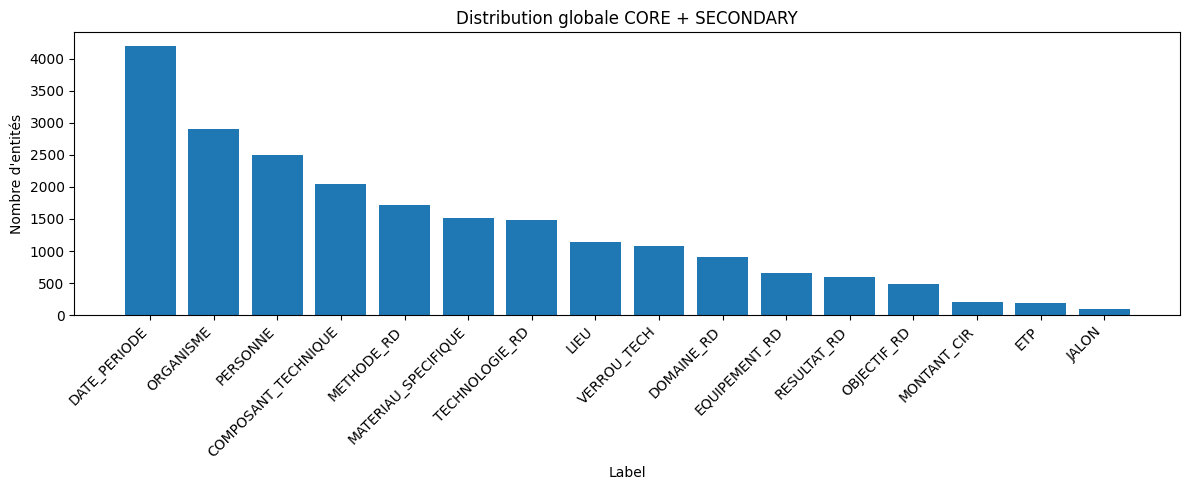

In [90]:
# Décision rapide : est-ce qu'on garde les labels secondaires ou CORE only ?

total_entities = len(df_entities)
secondary_labels = set(LABELS) - CORE_LABELS

df_decision_labels = (
    df_entities["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

df_decision_labels["ratio_%"] = (df_decision_labels["count"] / total_entities * 100).round(2)
df_decision_labels["type"] = df_decision_labels["label"].apply(
    lambda x: "CORE" if x in CORE_LABELS else "SECONDARY"
)

core_total = df_decision_labels[df_decision_labels["type"] == "CORE"]["count"].sum()
secondary_total = df_decision_labels[df_decision_labels["type"] == "SECONDARY"]["count"].sum()

print("Total entités :", total_entities)
print("CORE total    :", core_total, f"({core_total / total_entities * 100:.2f}%)")
print("SECONDARY total:", secondary_total, f"({secondary_total / total_entities * 100:.2f}%)")

display(df_decision_labels)

plt.figure(figsize=(12, 5))
plt.bar(df_decision_labels["label"], df_decision_labels["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribution globale CORE + SECONDARY")
plt.xlabel("Label")
plt.ylabel("Nombre d'entités")
plt.tight_layout()
plt.show()

Total entités CORE : 10494
Classe max         : 2048
Classe min         : 485
Ratio déséquilibre : 4.22


,label,count,ratio_%
0,COMPOSANT_TECHNIQUE,2048,19.52
1,METHODE_RD,1719,16.38
2,MATERIAU_SPECIFIQUE,1513,14.42
3,TECHNOLOGIE_RD,1491,14.21
4,VERROU_TECH,1074,10.23
5,DOMAINE_RD,912,8.69
6,EQUIPEMENT_RD,658,6.27
7,RESULTAT_RD,594,5.66
8,OBJECTIF_RD,485,4.62


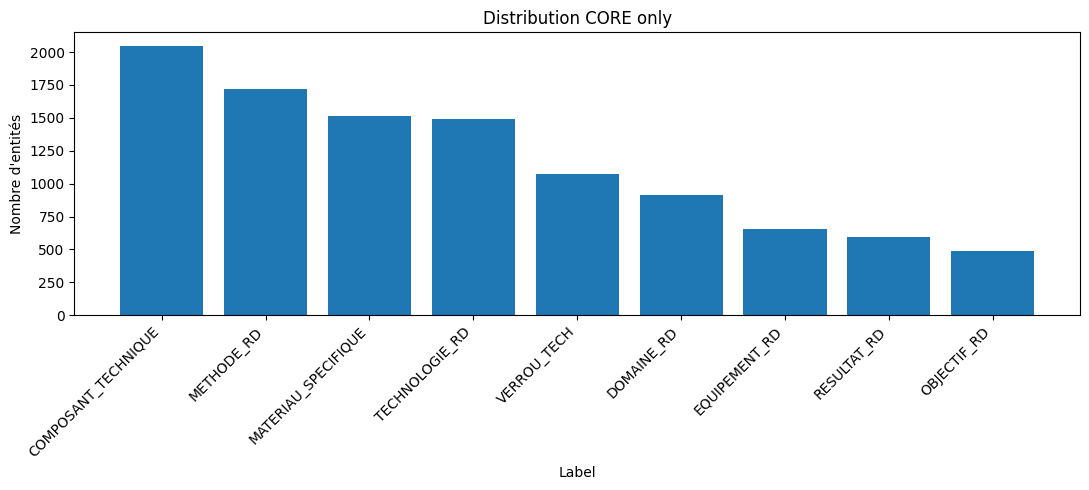


Décision automatique :
⚠️ Déséquilibre moyen. Split stratifié obligatoire + léger cap sur classes dominantes.


In [91]:
# Analyse rapide des labels CORE uniquement

df_core_only = df_entities[df_entities["label"].isin(CORE_LABELS)].copy()

df_core_decision = (
    df_core_only["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

df_core_decision["ratio_%"] = (df_core_decision["count"] / df_core_decision["count"].sum() * 100).round(2)

max_count = df_core_decision["count"].max()
min_count = df_core_decision["count"].min()
imbalance_ratio = round(max_count / min_count, 2)

print("Total entités CORE :", len(df_core_only))
print("Classe max         :", max_count)
print("Classe min         :", min_count)
print("Ratio déséquilibre :", imbalance_ratio)

display(df_core_decision)

plt.figure(figsize=(11, 5))
plt.bar(df_core_decision["label"], df_core_decision["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribution CORE only")
plt.xlabel("Label")
plt.ylabel("Nombre d'entités")
plt.tight_layout()
plt.show()

print("\nDécision automatique :")
if imbalance_ratio <= 3:
    print("✅ Répartition acceptable. On peut faire split stratifié CORE only.")
elif imbalance_ratio <= 5:
    print("⚠️ Déséquilibre moyen. Split stratifié obligatoire + léger cap sur classes dominantes.")
else:
    print("❌ Déséquilibre fort. Il faut équilibrer avant split.")

Chunks avant CORE only : 2917
Chunks après équilibrage: 2645
Entités après équilibrage: 9073


,label,count,ratio_%
2,COMPOSANT_TECHNIQUE,1400,15.43
1,METHODE_RD,1350,14.88
3,TECHNOLOGIE_RD,1300,14.33
7,MATERIAU_SPECIFIQUE,1300,14.33
4,VERROU_TECH,1074,11.84
8,DOMAINE_RD,912,10.05
5,EQUIPEMENT_RD,658,7.25
6,RESULTAT_RD,594,6.55
0,OBJECTIF_RD,485,5.35


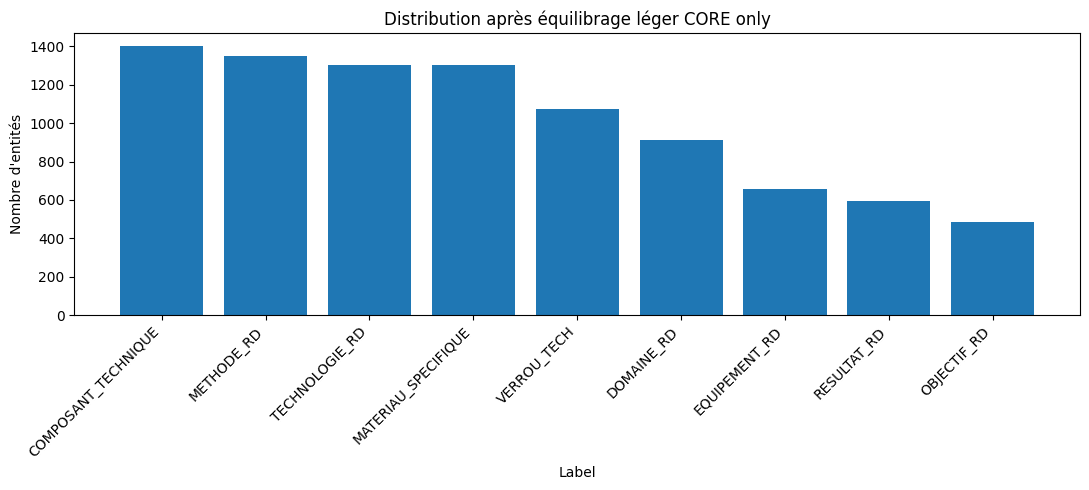

In [92]:
import random
from collections import Counter

random.seed(42)

# Caps proposés après analyse
LABEL_CAPS = {
    "COMPOSANT_TECHNIQUE": 1400,
    "METHODE_RD": 1350,
    "MATERIAU_SPECIFIQUE": 1300,
    "TECHNOLOGIE_RD": 1300,

    # On garde presque tout
    "VERROU_TECH": 1100,
    "DOMAINE_RD": 950,
    "EQUIPEMENT_RD": 700,
    "RESULTAT_RD": 650,
    "OBJECTIF_RD": 550,
}

balanced_items = []
label_counts = Counter()

# On mélange pour éviter que les premiers projets dominent
items_shuffled = all_items.copy()
random.shuffle(items_shuffled)

for item in items_shuffled:
    new_entities = []

    for ent in item.get("entities", []):
        label = ent.get("label")

        if label not in CORE_LABELS:
            continue

        if label_counts[label] < LABEL_CAPS[label]:
            new_entities.append(ent)
            label_counts[label] += 1

    if new_entities:
        item_copy = dict(item)
        item_copy["entities"] = new_entities
        balanced_items.append(item_copy)

df_balanced_counts = (
    pd.DataFrame([
        {"label": label, "count": count}
        for label, count in label_counts.items()
    ])
    .sort_values("count", ascending=False)
)

df_balanced_counts["ratio_%"] = (
    df_balanced_counts["count"] / df_balanced_counts["count"].sum() * 100
).round(2)

print("Chunks avant CORE only :", df_core_only["chunk_index"].nunique() if "chunk_index" in df_core_only.columns else "N/A")
print("Chunks après équilibrage:", len(balanced_items))
print("Entités après équilibrage:", sum(len(x["entities"]) for x in balanced_items))

display(df_balanced_counts)

plt.figure(figsize=(11, 5))
plt.bar(df_balanced_counts["label"], df_balanced_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribution après équilibrage léger CORE only")
plt.xlabel("Label")
plt.ylabel("Nombre d'entités")
plt.tight_layout()
plt.show()

Nouveau ratio déséquilibre: 2.89


,label,before,after,removed,reduction_%
0,COMPOSANT_TECHNIQUE,2048,1400,648,31.64
1,METHODE_RD,1719,1350,369,21.47
2,MATERIAU_SPECIFIQUE,1513,1300,213,14.08
3,TECHNOLOGIE_RD,1491,1300,191,12.81
4,VERROU_TECH,1074,1074,0,0.00
5,DOMAINE_RD,912,912,0,0.00
6,EQUIPEMENT_RD,658,658,0,0.00
7,RESULTAT_RD,594,594,0,0.00
8,OBJECTIF_RD,485,485,0,0.00


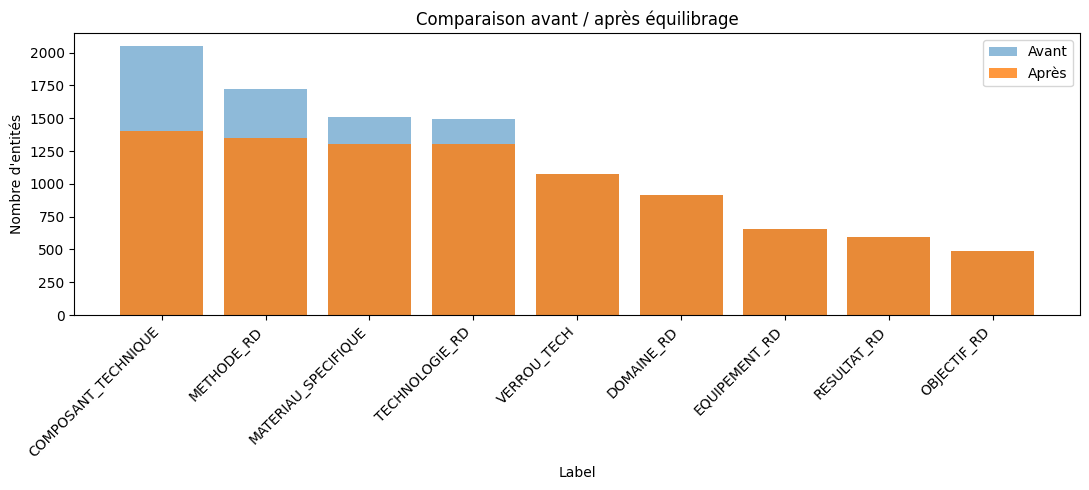

✅ Répartition maintenant acceptable pour split stratifié.


In [93]:
df_before_after = df_core_decision[["label", "count"]].rename(
    columns={"count": "before"}
).merge(
    df_balanced_counts[["label", "count"]].rename(columns={"count": "after"}),
    on="label",
    how="left"
)

df_before_after["after"] = df_before_after["after"].fillna(0).astype(int)
df_before_after["removed"] = df_before_after["before"] - df_before_after["after"]
df_before_after["reduction_%"] = (
    df_before_after["removed"] / df_before_after["before"] * 100
).round(2)

max_after = df_before_after["after"].max()
min_after = df_before_after["after"].min()
new_ratio = round(max_after / min_after, 2)

print("Nouveau ratio déséquilibre:", new_ratio)

display(df_before_after)

plt.figure(figsize=(11, 5))
plt.bar(df_before_after["label"], df_before_after["before"], alpha=0.5, label="Avant")
plt.bar(df_before_after["label"], df_before_after["after"], alpha=0.8, label="Après")
plt.xticks(rotation=45, ha="right")
plt.title("Comparaison avant / après équilibrage")
plt.xlabel("Label")
plt.ylabel("Nombre d'entités")
plt.legend()
plt.tight_layout()
plt.show()

if new_ratio <= 3:
    print("✅ Répartition maintenant acceptable pour split stratifié.")
else:
    print("⚠️ Encore un peu déséquilibré, on ajustera les caps.")

In [94]:
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd

# Pour chaque chunk, on prend le label CORE le plus fréquent comme label de stratification.
split_rows = []

for i, item in enumerate(balanced_items):
    labels = [ent["label"] for ent in item["entities"] if ent["label"] in CORE_LABELS]
    label_counts = Counter(labels)
    
    if not label_counts:
        continue
    
    dominant_label = label_counts.most_common(1)[0][0]
    
    split_rows.append({
        "idx": i,
        "project_id": item.get("project_id", ""),
        "dominant_label": dominant_label,
        "n_entities": len(labels),
    })

df_split_base = pd.DataFrame(split_rows)

print("Chunks disponibles pour split:", len(df_split_base))
display(df_split_base["dominant_label"].value_counts().reset_index(name="chunks"))

# Split 80% train / 20% temp
train_idx, temp_idx = train_test_split(
    df_split_base["idx"],
    test_size=0.20,
    random_state=42,
    stratify=df_split_base["dominant_label"]
)

df_temp = df_split_base[df_split_base["idx"].isin(temp_idx)]

# Split temp en 10% val / 10% test
val_idx, test_idx = train_test_split(
    df_temp["idx"],
    test_size=0.50,
    random_state=42,
    stratify=df_temp["dominant_label"]
)

train_items = [balanced_items[i] for i in train_idx]
val_items = [balanced_items[i] for i in val_idx]
test_items = [balanced_items[i] for i in test_idx]

print("Train chunks:", len(train_items))
print("Val chunks  :", len(val_items))
print("Test chunks :", len(test_items))

Chunks disponibles pour split: 2645


,dominant_label,chunks
0,METHODE_RD,458
1,TECHNOLOGIE_RD,349
2,MATERIAU_SPECIFIQUE,346
3,COMPOSANT_TECHNIQUE,308
4,VERROU_TECH,300
5,DOMAINE_RD,292
6,EQUIPEMENT_RD,210
7,RESULTAT_RD,197
8,OBJECTIF_RD,185


Train chunks: 2116
Val chunks  : 264
Test chunks : 265


,label,all,train,val,test,train_%,val_%,test_%
0,COMPOSANT_TECHNIQUE,1400,1122,141,137,80.14,10.07,9.79
4,METHODE_RD,1350,1067,137,146,79.04,10.15,10.81
3,MATERIAU_SPECIFIQUE,1300,1066,124,110,82.00,9.54,8.46
7,TECHNOLOGIE_RD,1300,991,170,139,76.23,13.08,10.69
8,VERROU_TECH,1074,854,105,115,79.52,9.78,10.71
1,DOMAINE_RD,912,691,124,97,75.77,13.60,10.64
2,EQUIPEMENT_RD,658,509,76,73,77.36,11.55,11.09
6,RESULTAT_RD,594,469,59,66,78.96,9.93,11.11
5,OBJECTIF_RD,485,393,47,45,81.03,9.69,9.28


Total entités all  : 9073
Total entités train: 7162
Total entités val  : 983
Total entités test : 928


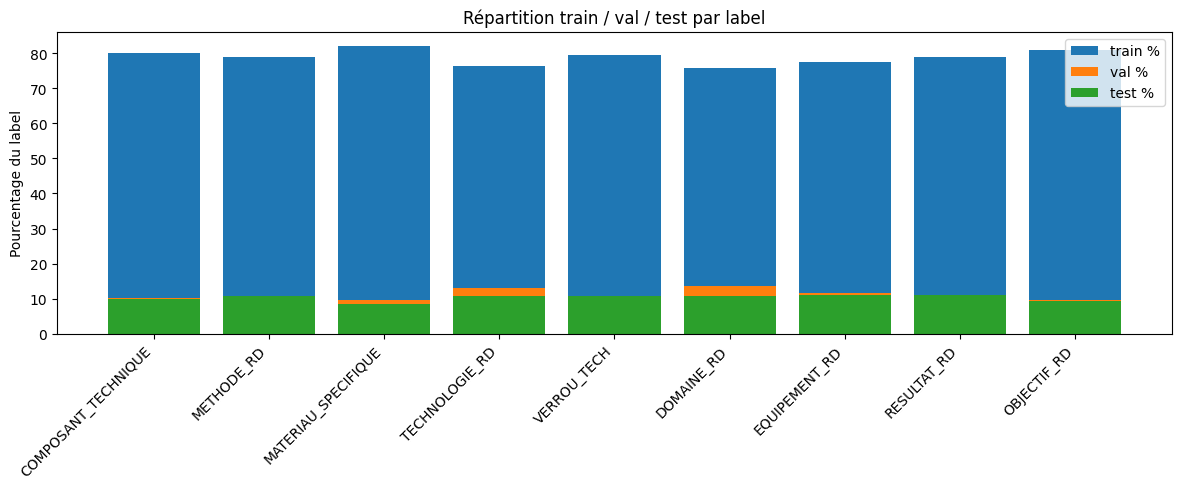

In [95]:
def count_entities_by_label(items):
    c = Counter()
    for item in items:
        for ent in item["entities"]:
            if ent["label"] in CORE_LABELS:
                c[ent["label"]] += 1
    return c

all_counts = count_entities_by_label(balanced_items)
train_counts = count_entities_by_label(train_items)
val_counts = count_entities_by_label(val_items)
test_counts = count_entities_by_label(test_items)

rows = []

for label in sorted(all_counts.keys()):
    total = all_counts[label]
    rows.append({
        "label": label,
        "all": total,
        "train": train_counts[label],
        "val": val_counts[label],
        "test": test_counts[label],
        "train_%": round(train_counts[label] / total * 100, 2),
        "val_%": round(val_counts[label] / total * 100, 2),
        "test_%": round(test_counts[label] / total * 100, 2),
    })

df_split_check = pd.DataFrame(rows).sort_values("all", ascending=False)

display(df_split_check)

print("Total entités all  :", sum(all_counts.values()))
print("Total entités train:", sum(train_counts.values()))
print("Total entités val  :", sum(val_counts.values()))
print("Total entités test :", sum(test_counts.values()))

plt.figure(figsize=(12, 5))
plt.bar(df_split_check["label"], df_split_check["train_%"], label="train %")
plt.bar(df_split_check["label"], df_split_check["val_%"], label="val %")
plt.bar(df_split_check["label"], df_split_check["test_%"], label="test %")
plt.xticks(rotation=45, ha="right")
plt.title("Répartition train / val / test par label")
plt.ylabel("Pourcentage du label")
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
from pathlib import Path
import json
from collections import Counter

OUTPUT_DIR = Path(r"C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_ALL = OUTPUT_DIR / "gliner_cir_all.json"
OUT_TRAIN = OUTPUT_DIR / "gliner_cir_train.json"
OUT_VAL = OUTPUT_DIR / "gliner_cir_val.json"
OUT_TEST = OUTPUT_DIR / "gliner_cir_test.json"
OUT_REPORT = OUTPUT_DIR / "prepare_report.json"

def to_gliner_format(items):
    output = []
    
    for item in items:
        text = item.get("text", "")
        entities = []
        
        for ent in item.get("entities", []):
            label = ent.get("label")
            
            if label not in CORE_LABELS:
                continue
            
            start = ent.get("start")
            end = ent.get("end")
            
            if not isinstance(start, int) or not isinstance(end, int):
                continue
            
            if start < 0 or end <= start or end > len(text):
                continue
            
            entities.append({
                "start": start,
                "end": end,
                "label": label,
                "text": text[start:end],
            })
        
        if entities:
            output.append({
                "text": text,
                "entities": entities,
                "metadata": {
                    "project_id": item.get("project_id", ""),
                    "annotation_id": item.get("annotation_id", ""),
                    "source_file": item.get("source_file", ""),
                    "annotation_status": item.get("annotation_status", ""),
                }
            })
    
    return output

all_out = to_gliner_format(balanced_items)
train_out = to_gliner_format(train_items)
val_out = to_gliner_format(val_items)
test_out = to_gliner_format(test_items)

def save_json(path, data):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

save_json(OUT_ALL, all_out)
save_json(OUT_TRAIN, train_out)
save_json(OUT_VAL, val_out)
save_json(OUT_TEST, test_out)

report = {
    "strategy": "CORE only + light label caps + stratified split by dominant label",
    "labels_used": sorted(list(CORE_LABELS)),
    "removed_secondary_labels": sorted(list(set(LABELS) - CORE_LABELS)),
    "label_caps": LABEL_CAPS,
    "counts": {
        "all_chunks": len(all_out),
        "train_chunks": len(train_out),
        "val_chunks": len(val_out),
        "test_chunks": len(test_out),
        "all_entities": sum(len(x["entities"]) for x in all_out),
        "train_entities": sum(len(x["entities"]) for x in train_out),
        "val_entities": sum(len(x["entities"]) for x in val_out),
        "test_entities": sum(len(x["entities"]) for x in test_out),
    },
    "split_check": df_split_check.to_dict(orient="records"),
}

save_json(OUT_REPORT, report)

print("✅ Export terminé")
print("All   :", OUT_ALL)
print("Train :", OUT_TRAIN)
print("Val   :", OUT_VAL)
print("Test  :", OUT_TEST)
print("Report:", OUT_REPORT)
print(report["counts"])

✅ Export terminé
All   : C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced\gliner_cir_all.json
Train : C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced\gliner_cir_train.json
Val   : C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced\gliner_cir_val.json
Test  : C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced\gliner_cir_test.json
Report: C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced\prepare_report.json
{'all_chunks': 2645, 'train_chunks': 2116, 'val_chunks': 264, 'test_chunks': 265, 'all_entities': 9073, 'train_entities': 7162, 'val_entities': 983, 'test_entities': 928}


In [97]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

train_check = load_json(OUT_TRAIN)
val_check = load_json(OUT_VAL)
test_check = load_json(OUT_TEST)

def final_label_counts(data):
    c = Counter()
    for item in data:
        for ent in item["entities"]:
            c[ent["label"]] += 1
    return c

print("Train chunks:", len(train_check))
print("Val chunks  :", len(val_check))
print("Test chunks :", len(test_check))

print("\nTrain labels:")
print(final_label_counts(train_check))

print("\nVal labels:")
print(final_label_counts(val_check))

print("\nTest labels:")
print(final_label_counts(test_check))

# Vérifier s'il reste des labels secondaires
all_exported_labels = set()
for dataset in [train_check, val_check, test_check]:
    for item in dataset:
        for ent in item["entities"]:
            all_exported_labels.add(ent["label"])

print("\nLabels exportés:")
print(sorted(all_exported_labels))

secondary_left = all_exported_labels - CORE_LABELS
print("\nLabels secondaires restants:", secondary_left)

if not secondary_left:
    print("✅ Dataset final propre : CORE only.")
else:
    print("⚠️ Attention : labels secondaires détectés.")

Train chunks: 2116
Val chunks  : 264
Test chunks : 265

Train labels:
Counter({'COMPOSANT_TECHNIQUE': 1122, 'METHODE_RD': 1067, 'MATERIAU_SPECIFIQUE': 1066, 'TECHNOLOGIE_RD': 991, 'VERROU_TECH': 854, 'DOMAINE_RD': 691, 'EQUIPEMENT_RD': 509, 'RESULTAT_RD': 469, 'OBJECTIF_RD': 393})

Val labels:
Counter({'TECHNOLOGIE_RD': 170, 'COMPOSANT_TECHNIQUE': 141, 'METHODE_RD': 137, 'DOMAINE_RD': 124, 'MATERIAU_SPECIFIQUE': 124, 'VERROU_TECH': 105, 'EQUIPEMENT_RD': 76, 'RESULTAT_RD': 59, 'OBJECTIF_RD': 47})

Test labels:
Counter({'METHODE_RD': 146, 'TECHNOLOGIE_RD': 139, 'COMPOSANT_TECHNIQUE': 137, 'VERROU_TECH': 115, 'MATERIAU_SPECIFIQUE': 110, 'DOMAINE_RD': 97, 'EQUIPEMENT_RD': 73, 'RESULTAT_RD': 66, 'OBJECTIF_RD': 45})

Labels exportés:
['COMPOSANT_TECHNIQUE', 'DOMAINE_RD', 'EQUIPEMENT_RD', 'MATERIAU_SPECIFIQUE', 'METHODE_RD', 'OBJECTIF_RD', 'RESULTAT_RD', 'TECHNOLOGIE_RD', 'VERROU_TECH']

Labels secondaires restants: set()
✅ Dataset final propre : CORE only.


In [98]:
MAX_TOKENS_GLINER = 384

def count_tokens_simple(text):
    return len(str(text).split())

def long_chunks_report(data, name):
    rows = []
    for i, item in enumerate(data):
        n_tokens = count_tokens_simple(item.get("text", ""))
        n_entities = len(item.get("entities", []))
        if n_tokens > MAX_TOKENS_GLINER:
            rows.append({
                "split": name,
                "idx": i,
                "tokens": n_tokens,
                "entities": n_entities,
                "project_id": item.get("metadata", {}).get("project_id", item.get("project_id", "")),
                "preview": item.get("text", "")[:150]
            })
    return rows

long_rows = []
long_rows += long_chunks_report(train_raw, "train")
long_rows += long_chunks_report(val_raw, "val")
long_rows += long_chunks_report(test_raw, "test")

df_long_chunks = pd.DataFrame(long_rows)

print("Chunks longs total:", len(df_long_chunks))
display(df_long_chunks.sort_values("tokens", ascending=False).head(30))

print("Entités dans chunks longs:", df_long_chunks["entities"].sum() if len(df_long_chunks) else 0)

Chunks longs total: 22


,split,idx,tokens,entities,project_id,preview
8,train,1080,928,2,projet_3_,[TABLEAU]\n| | Raw data | Raw data | Raw data ...
21,test,223,928,2,projet_3_,[TABLEAU]\n| | Raw data | Raw data | Raw data ...
15,train,1765,928,1,projet_3_,[TABLEAU]\n| | Raw data | Raw data | Raw data ...
18,train,1936,928,1,projet_3_,[TABLEAU]\n| | Raw data | Raw data | Raw data ...
7,train,978,928,2,projet_3_,[TABLEAU]\n| | Raw data | Raw data | Raw data ...
16,train,1840,587,2,projet_3_,[TABLEAU 1]\n| Group | Rat ID | Treatment admi...
3,train,355,531,11,projet_25_,[TABLEAU]\n| Axe central | Fonctionnalité / So...
20,test,15,515,16,projet_4_,[TABLEAU]\n| code1 | DOMAINES niv1 | code2 | S...
19,val,73,515,16,projet_4_,[TABLEAU]\n| code1 | DOMAINES niv1 | code2 | S...
0,train,89,511,2,projet_7_,| | |\n| | | 4 | | 1 | Rondelle | | | | G58025...


Entités dans chunks longs: 80


Cellule 9 — Imports fine-tuning + chemins

In [99]:
import os
import json
import re
import inspect
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from gliner import GLiNER

from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

MODEL_NAME = "urchade/gliner_multi-v2.1"

DATA_DIR = Path(r"C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced")

TRAIN_PATH = DATA_DIR / "gliner_cir_train.json"
VAL_PATH   = DATA_DIR / "gliner_cir_val.json"
TEST_PATH  = DATA_DIR / "gliner_cir_test.json"

OUTPUT_MODEL_DIR = Path(r"C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced")
FINAL_MODEL_DIR = OUTPUT_MODEL_DIR / "final_model"
OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

LABELS_CORE = [
    "VERROU_TECH",
    "METHODE_RD",
    "TECHNOLOGIE_RD",
    "EQUIPEMENT_RD",
    "COMPOSANT_TECHNIQUE",
    "MATERIAU_SPECIFIQUE",
    "DOMAINE_RD",
    "RESULTAT_RD",
    "OBJECTIF_RD",
]

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Train:", TRAIN_PATH)
print("Val  :", VAL_PATH)
print("Test :", TEST_PATH)
print("Output model:", FINAL_MODEL_DIR)

CUDA available: True
GPU: NVIDIA RTX 1000 Ada Generation Laptop GPU
Train: C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced\gliner_cir_train.json
Val  : C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced\gliner_cir_val.json
Test : C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced\gliner_cir_test.json
Output model: C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced\final_model


In [100]:
import re
from copy import deepcopy

TOKEN_PATTERN = re.compile(r"\S+")

MAX_WINDOW_TOKENS = 350
WINDOW_OVERLAP = 50

def tokenize_offsets(text):
    tokens = []
    offsets = []
    for m in TOKEN_PATTERN.finditer(text):
        tokens.append(m.group())
        offsets.append((m.start(), m.end()))
    return tokens, offsets

def split_item_preserve_entities(item, max_tokens=350, overlap=50):
    text = item.get("text", "")
    entities = item.get("entities", [])
    
    tokens, offsets = tokenize_offsets(text)
    
    if len(tokens) <= max_tokens:
        return [item]
    
    new_items = []
    start_tok = 0
    window_id = 0
    
    while start_tok < len(tokens):
        end_tok = min(start_tok + max_tokens, len(tokens))
        
        char_start = offsets[start_tok][0]
        char_end = offsets[end_tok - 1][1]
        sub_text = text[char_start:char_end]
        
        sub_entities = []
        
        for ent in entities:
            ent_start = ent.get("start")
            ent_end = ent.get("end")
            label = ent.get("label")
            
            if not isinstance(ent_start, int) or not isinstance(ent_end, int):
                continue
            
            # Garder uniquement les entités entièrement dans la fenêtre
            if ent_start >= char_start and ent_end <= char_end:
                new_ent = dict(ent)
                new_ent["start"] = ent_start - char_start
                new_ent["end"] = ent_end - char_start
                new_ent["text"] = sub_text[new_ent["start"]:new_ent["end"]]
                sub_entities.append(new_ent)
        
        if sub_entities:
            new_item = deepcopy(item)
            new_item["text"] = sub_text
            new_item["entities"] = sub_entities
            
            old_meta = new_item.get("metadata", {})
            if old_meta is None:
                old_meta = {}
            
            new_item["metadata"] = {
                **old_meta,
                "split_from_long_chunk": True,
                "window_id": window_id,
                "original_tokens": len(tokens),
                "window_tokens": len(sub_text.split()),
            }
            
            new_items.append(new_item)
        
        if end_tok == len(tokens):
            break
        
        start_tok = end_tok - overlap
        window_id += 1
    
    return new_items

def split_dataset_long_chunks(data, max_tokens=350, overlap=50):
    output = []
    stats = {
        "input_chunks": len(data),
        "output_chunks": 0,
        "long_chunks_split": 0,
        "entities_before": sum(len(x.get("entities", [])) for x in data),
        "entities_after": 0,
        "chunks_without_entities_after_split": 0,
    }
    
    for item in data:
        n_tokens = len(str(item.get("text", "")).split())
        
        if n_tokens > max_tokens:
            stats["long_chunks_split"] += 1
        
        parts = split_item_preserve_entities(item, max_tokens=max_tokens, overlap=overlap)
        
        if not parts:
            stats["chunks_without_entities_after_split"] += 1
        
        output.extend(parts)
    
    stats["output_chunks"] = len(output)
    stats["entities_after"] = sum(len(x.get("entities", [])) for x in output)
    
    return output, stats

train_raw_fixed, train_fix_stats = split_dataset_long_chunks(train_raw, MAX_WINDOW_TOKENS, WINDOW_OVERLAP)
val_raw_fixed, val_fix_stats = split_dataset_long_chunks(val_raw, MAX_WINDOW_TOKENS, WINDOW_OVERLAP)
test_raw_fixed, test_fix_stats = split_dataset_long_chunks(test_raw, MAX_WINDOW_TOKENS, WINDOW_OVERLAP)

print("Train stats:", train_fix_stats)
print("Val stats  :", val_fix_stats)
print("Test stats :", test_fix_stats)

Train stats: {'input_chunks': 2116, 'output_chunks': 2119, 'long_chunks_split': 20, 'entities_before': 7162, 'entities_after': 7166, 'chunks_without_entities_after_split': 0}
Val stats  : {'input_chunks': 264, 'output_chunks': 264, 'long_chunks_split': 1, 'entities_before': 983, 'entities_after': 983, 'chunks_without_entities_after_split': 0}
Test stats : {'input_chunks': 265, 'output_chunks': 265, 'long_chunks_split': 2, 'entities_before': 928, 'entities_after': 928, 'chunks_without_entities_after_split': 0}


In [101]:
def check_max_tokens(data, name):
    lengths = [len(str(item.get("text", "")).split()) for item in data]
    print(name)
    print("chunks:", len(data))
    print("max tokens:", max(lengths))
    print("chunks > 384:", sum(1 for x in lengths if x > 384))
    print("entities:", sum(len(x.get("entities", [])) for x in data))
    print()

check_max_tokens(train_raw_fixed, "train_fixed")
check_max_tokens(val_raw_fixed, "val_fixed")
check_max_tokens(test_raw_fixed, "test_fixed")

train_fixed
chunks: 2119
max tokens: 350
chunks > 384: 0
entities: 7166

val_fixed
chunks: 264
max tokens: 350
chunks > 384: 0
entities: 983

test_fixed
chunks: 265
max tokens: 350
chunks > 384: 0
entities: 928



Cellule 11 — Conversion JSON vers format GLiNER

In [102]:
train_data, train_stats = convert_to_gliner_format(train_raw_fixed)
val_data, val_stats = convert_to_gliner_format(val_raw_fixed)
test_data, test_stats = convert_to_gliner_format(test_raw_fixed)

print("Train converted:", train_stats)
print("Val converted  :", val_stats)
print("Test converted :", test_stats)

print("Train examples:", len(train_data))
print("Val examples  :", len(val_data))
print("Test examples :", len(test_data))

Train converted: {'converted': 2119, 'skipped_bad_spans': 0, 'skipped_empty': 0}
Val converted  : {'converted': 264, 'skipped_bad_spans': 0, 'skipped_empty': 0}
Test converted : {'converted': 265, 'skipped_bad_spans': 0, 'skipped_empty': 0}
Train examples: 2119
Val examples  : 264
Test examples : 265


In [103]:
from gliner.training.trainer import TrainingArguments
import inspect

# Détecter le bon nom du paramètre selon ta version transformers / GLiNER
ta_signature = inspect.signature(TrainingArguments.__init__)
ta_params = ta_signature.parameters

if "eval_strategy" in ta_params:
    EVAL_STRATEGY_KEY = "eval_strategy"
elif "evaluation_strategy" in ta_params:
    EVAL_STRATEGY_KEY = "evaluation_strategy"
else:
    EVAL_STRATEGY_KEY = None

print("Evaluation strategy key:", EVAL_STRATEGY_KEY)

Evaluation strategy key: eval_strategy


In [104]:
MODEL_NAME = "urchade/gliner_multi-v2.1"

TEST_OUTPUT_MODEL_DIR = Path(r"C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_test_500")
TEST_FINAL_MODEL_DIR = TEST_OUTPUT_MODEL_DIR / "final_model"
TEST_OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

model = GLiNER.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    model = model.to("cuda")

MAX_STEPS = 500
BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1

train_params = {
    "train_dataset": train_data,
    "eval_dataset": val_data,
    "output_dir": str(TEST_OUTPUT_MODEL_DIR),

    "learning_rate": 1e-5,
    "others_lr": 5e-5,
    "weight_decay": 0.01,

    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": EVAL_BATCH_SIZE,

    "max_steps": MAX_STEPS,
    "logging_steps": 50,
    "eval_steps": 100,

    "save_steps": 250,
    "save_total_limit": 2,

    "dataloader_num_workers": 0,
    "report_to": "none",
}

if EVAL_STRATEGY_KEY is not None:
    train_params[EVAL_STRATEGY_KEY] = "steps"

trainer = model.train_model(**train_params)

model.save_pretrained(str(TEST_FINAL_MODEL_DIR))

print("✅ Test training 500 steps terminé")
print("Model saved to:", TEST_FINAL_MODEL_DIR)

c:\EnnoSmart\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


KeyboardInterrupt: 

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,12.700237,439.713104,4.900000e-05,0.023596,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11.509823,174.282440,4.455556e-05,0.047192,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,0.047192,100,13.092487,19.3299,13.658,13.658,NaN,NaN,NaN,NaN,NaN
3,15.475203,253.980453,3.900000e-05,0.070788,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10.519371,300.116943,3.344444e-05,0.094384,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,0.094384,200,12.648408,25.4421,10.377,10.377,NaN,NaN,NaN,NaN,NaN
6,9.252707,121.687157,2.788889e-05,0.117980,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,12.837994,241.053909,2.233333e-05,0.141576,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,0.141576,300,11.378880,25.6991,10.273,10.273,NaN,NaN,NaN,NaN,NaN
9,10.792111,476.417908,1.677778e-05,0.165172,350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


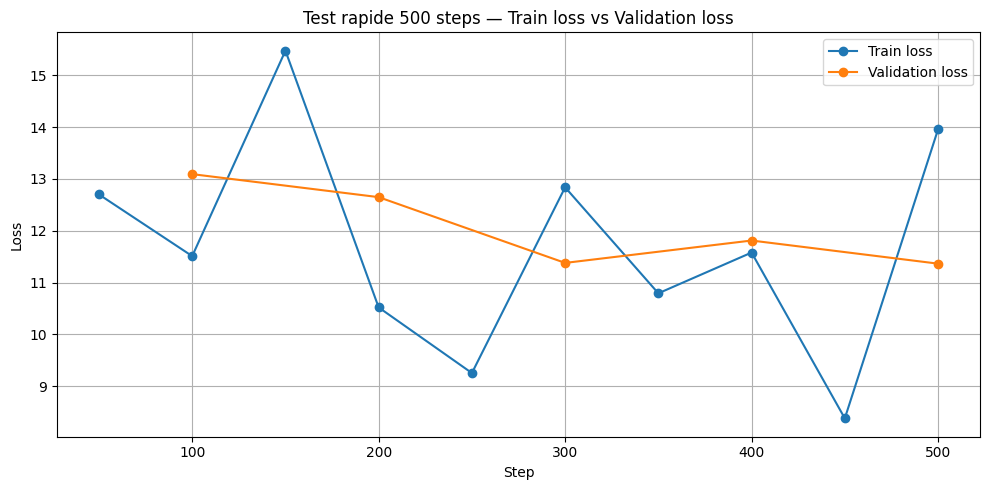

In [ ]:
log_history = trainer.state.log_history
df_logs_test = pd.DataFrame(log_history)

display(df_logs_test)

train_loss_df = df_logs_test[df_logs_test["loss"].notna()][["step", "loss"]].copy() if "loss" in df_logs_test.columns else pd.DataFrame()
val_loss_df = df_logs_test[df_logs_test["eval_loss"].notna()][["step", "eval_loss"]].copy() if "eval_loss" in df_logs_test.columns else pd.DataFrame()

plt.figure(figsize=(10, 5))

if len(train_loss_df):
    plt.plot(train_loss_df["step"], train_loss_df["loss"], marker="o", label="Train loss")

if len(val_loss_df):
    plt.plot(val_loss_df["step"], val_loss_df["eval_loss"], marker="o", label="Validation loss")

plt.title("Test rapide 500 steps — Train loss vs Validation loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [105]:
FIXED_DATA_DIR = Path(r"C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced_fixed")
FIXED_DATA_DIR.mkdir(parents=True, exist_ok=True)

FIXED_TRAIN_PATH = FIXED_DATA_DIR / "gliner_cir_train_fixed.json"
FIXED_VAL_PATH = FIXED_DATA_DIR / "gliner_cir_val_fixed.json"
FIXED_TEST_PATH = FIXED_DATA_DIR / "gliner_cir_test_fixed.json"

def save_json(path, data):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

save_json(FIXED_TRAIN_PATH, train_raw_fixed)
save_json(FIXED_VAL_PATH, val_raw_fixed)
save_json(FIXED_TEST_PATH, test_raw_fixed)

print("✅ Fixed datasets saved")
print(FIXED_TRAIN_PATH)
print(FIXED_VAL_PATH)
print(FIXED_TEST_PATH)

✅ Fixed datasets saved
C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced_fixed\gliner_cir_train_fixed.json
C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced_fixed\gliner_cir_val_fixed.json
C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced_fixed\gliner_cir_test_fixed.json


In [106]:
import gc
import torch

try:
    del trainer
except:
    pass

try:
    del model
except:
    pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU cache vidé")

GPU cache vidé


In [107]:
from gliner import GLiNER
from gliner.training.trainer import TrainingArguments
import inspect

OUTPUT_MODEL_DIR = Path(r"C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_fixed_final")
FINAL_MODEL_DIR = OUTPUT_MODEL_DIR / "final_model"
OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Détecter eval_strategy ou evaluation_strategy
ta_signature = inspect.signature(TrainingArguments.__init__)
ta_params = ta_signature.parameters

if "eval_strategy" in ta_params:
    EVAL_STRATEGY_KEY = "eval_strategy"
elif "evaluation_strategy" in ta_params:
    EVAL_STRATEGY_KEY = "evaluation_strategy"
else:
    EVAL_STRATEGY_KEY = None

model = GLiNER.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    model = model.to("cuda")

EPOCHS = 2
BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1

steps_per_epoch = len(train_data) // BATCH_SIZE
MAX_STEPS = steps_per_epoch * EPOCHS

print("Steps per epoch:", steps_per_epoch)
print("Epochs:", EPOCHS)
print("Max steps:", MAX_STEPS)

train_params = {
    "train_dataset": train_data,
    "eval_dataset": val_data,
    "output_dir": str(OUTPUT_MODEL_DIR),

    "learning_rate": 1e-5,
    "others_lr": 5e-5,
    "weight_decay": 0.01,

    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": EVAL_BATCH_SIZE,

    "max_steps": MAX_STEPS,
    "logging_steps": 50,
    "eval_steps": 100,

    "save_steps": 300,
    "save_total_limit": 3,

    "dataloader_num_workers": 0,
    "report_to": "none",
}

if EVAL_STRATEGY_KEY is not None:
    train_params[EVAL_STRATEGY_KEY] = "steps"

trainer = model.train_model(**train_params)

model.save_pretrained(str(FINAL_MODEL_DIR))

print("✅ Fine-tuning final terminé")
print("Model saved to:", FINAL_MODEL_DIR)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1, 'pad_token_id': 0}.


Steps per epoch: 2119
Epochs: 2
Max steps: 4238


Step,Training Loss,Validation Loss
100,11.754496,14.541652
200,11.369980,12.865604
300,13.778490,12.182116
400,12.802213,13.701492
500,15.167817,11.060744
600,14.905437,12.057889
700,11.414823,11.247048
800,11.878898,11.938140
900,9.772940,11.051063
1000,8.858201,13.470675


✅ Fine-tuning final terminé
Model saved to: C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_fixed_final\final_model


trainer_state files trouvés: 3
C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_fixed_final\checkpoint-3900\trainer_state.json
C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_fixed_final\checkpoint-4200\trainer_state.json
C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_fixed_final\checkpoint-4238\trainer_state.json

Fichier utilisé: C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_fixed_final\checkpoint-4238\trainer_state.json


,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
96,1.533742,168.093658,1.296539e-05,4.276948,3250,NaN,NaN,NaN,NaN
97,1.557338,347.676788,1.230991e-05,8.068398,3300,NaN,NaN,NaN,NaN
98,1.557338,NaN,NaN,NaN,3300,10.543694,23.2090,11.375,11.375
99,1.580934,1316.831543,1.165443e-05,9.698127,3350,NaN,NaN,NaN,NaN
100,1.604530,319.504730,1.099895e-05,7.355048,3400,NaN,NaN,NaN,NaN
101,1.604530,NaN,NaN,NaN,3400,10.421764,22.1827,11.901,11.901
102,1.628126,1435.657227,1.034347e-05,8.450468,3450,NaN,NaN,NaN,NaN
103,1.651723,0.042744,9.687992e-06,5.997100,3500,NaN,NaN,NaN,NaN
104,1.651723,NaN,NaN,NaN,3500,10.782491,22.9783,11.489,11.489
105,1.675319,149.837250,9.032512e-06,6.074427,3550,NaN,NaN,NaN,NaN


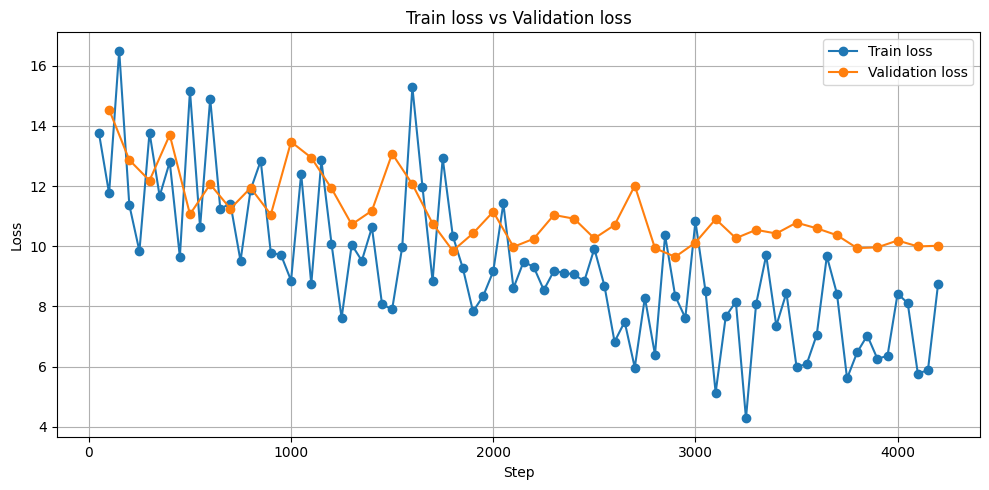

In [9]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_MODEL_DIR = Path(r"C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_fixed_final")

# Chercher tous les trainer_state.json dans les checkpoints
state_files = list(OUTPUT_MODEL_DIR.glob("checkpoint-*/trainer_state.json"))

print("trainer_state files trouvés:", len(state_files))
for p in state_files:
    print(p)

if not state_files:
    raise FileNotFoundError("Aucun trainer_state.json trouvé dans les checkpoints.")

# Prendre le plus récent checkpoint selon le numéro
def checkpoint_step(path):
    return int(path.parent.name.replace("checkpoint-", ""))

latest_state_file = sorted(state_files, key=checkpoint_step)[-1]

print("\nFichier utilisé:", latest_state_file)

with open(latest_state_file, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)

log_history = trainer_state.get("log_history", [])

df_logs = pd.DataFrame(log_history)

display(df_logs.tail(30))

train_loss_df = (
    df_logs[df_logs["loss"].notna()][["step", "loss"]].copy()
    if "loss" in df_logs.columns else pd.DataFrame()
)

val_loss_df = (
    df_logs[df_logs["eval_loss"].notna()][["step", "eval_loss"]].copy()
    if "eval_loss" in df_logs.columns else pd.DataFrame()
)

plt.figure(figsize=(10, 5))

if len(train_loss_df):
    plt.plot(train_loss_df["step"], train_loss_df["loss"], marker="o", label="Train loss")

if len(val_loss_df):
    plt.plot(val_loss_df["step"], val_loss_df["eval_loss"], marker="o", label="Validation loss")

plt.title("Train loss vs Validation loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from gliner import GLiNER

FINAL_MODEL_DIR = Path(r"C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_fixed_final\final_model")

FIXED_DATA_DIR = Path(r"C:\EnnoSmart\train\final_gliner_cir_dataset_1_32_core_balanced_fixed")
FIXED_TRAIN_PATH = FIXED_DATA_DIR / "gliner_cir_train_fixed.json"
FIXED_VAL_PATH = FIXED_DATA_DIR / "gliner_cir_val_fixed.json"
FIXED_TEST_PATH = FIXED_DATA_DIR / "gliner_cir_test_fixed.json"

LABELS_CORE = [
    "VERROU_TECH",
    "METHODE_RD",
    "TECHNOLOGIE_RD",
    "EQUIPEMENT_RD",
    "COMPOSANT_TECHNIQUE",
    "MATERIAU_SPECIFIQUE",
    "DOMAINE_RD",
    "RESULTAT_RD",
    "OBJECTIF_RD",
]

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

train_raw_fixed = load_json(FIXED_TRAIN_PATH)
val_raw_fixed = load_json(FIXED_VAL_PATH)
test_raw_fixed = load_json(FIXED_TEST_PATH)

model_eval = GLiNER.from_pretrained(str(FINAL_MODEL_DIR))

if torch.cuda.is_available():
    model_eval = model_eval.to("cuda")

print("✅ Modèle chargé :", FINAL_MODEL_DIR)
print("Train:", len(train_raw_fixed))
print("Val  :", len(val_raw_fixed))
print("Test :", len(test_raw_fixed))

c:\EnnoSmart\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Modèle chargé : C:\EnnoSmart\train\models\gliner_cir_1_32_core_balanced_fixed_final\final_model
Train: 2119
Val  : 264
Test : 265


In [ ]:
def gold_entities_from_item(item):
    gold = set()
    
    for ent in item.get("entities", []):
        label = ent.get("label")
        start = ent.get("start")
        end = ent.get("end")
        
        if label in LABELS_CORE and isinstance(start, int) and isinstance(end, int):
            gold.add((start, end, label))
    
    return gold


def pred_entities_from_model(model, text, threshold=0.5):
    preds = model.predict_entities(
        text,
        LABELS_CORE,
        threshold=threshold
    )
    
    pred_set = set()
    
    for p in preds:
        start = p.get("start")
        end = p.get("end")
        label = p.get("label")
        
        if label in LABELS_CORE and isinstance(start, int) and isinstance(end, int):
            pred_set.add((start, end, label))
    
    return pred_set


def evaluate_ner_exact(model, dataset_raw, threshold=0.5, max_items=None):
    if max_items is not None:
        dataset_raw = dataset_raw[:max_items]
    
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    per_label = {
        label: {"tp": 0, "fp": 0, "fn": 0}
        for label in LABELS_CORE
    }
    
    for item in dataset_raw:
        text = item.get("text", "")
        
        gold = gold_entities_from_item(item)
        pred = pred_entities_from_model(model, text, threshold=threshold)
        
        tp_set = gold & pred
        fp_set = pred - gold
        fn_set = gold - pred
        
        total_tp += len(tp_set)
        total_fp += len(fp_set)
        total_fn += len(fn_set)
        
        for _, _, label in tp_set:
            per_label[label]["tp"] += 1
        
        for _, _, label in fp_set:
            per_label[label]["fp"] += 1
        
        for _, _, label in fn_set:
            per_label[label]["fn"] += 1
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    
    rows = []
    
    for label, d in per_label.items():
        p = d["tp"] / (d["tp"] + d["fp"]) if (d["tp"] + d["fp"]) else 0
        r = d["tp"] / (d["tp"] + d["fn"]) if (d["tp"] + d["fn"]) else 0
        f = 2 * p * r / (p + r) if (p + r) else 0
        
        rows.append({
            "label": label,
            "precision": round(p, 4),
            "recall": round(r, 4),
            "f1": round(f, 4),
            "tp": d["tp"],
            "fp": d["fp"],
            "fn": d["fn"],
        })
    
    return {
        "threshold": threshold,
        "micro_precision": precision,
        "micro_recall": recall,
        "micro_f1": f1,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "per_label": pd.DataFrame(rows).sort_values("f1", ascending=False),
    }

print("✅ Fonctions métriques chargées")

✅ Fonctions métriques chargées


In [3]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

threshold_results = []

for th in thresholds:
    res = evaluate_ner_exact(model_eval, val_raw_fixed, threshold=th)
    threshold_results.append({
        "threshold": th,
        "precision": round(res["micro_precision"], 4),
        "recall": round(res["micro_recall"], 4),
        "f1": round(res["micro_f1"], 4),
        "tp": res["tp"],
        "fp": res["fp"],
        "fn": res["fn"],
    })

df_thresholds = pd.DataFrame(threshold_results)
display(df_thresholds)

best_threshold = df_thresholds.sort_values("f1", ascending=False).iloc[0]["threshold"]
print("✅ Best threshold:", best_threshold)

plt.figure(figsize=(8, 5))
plt.plot(df_thresholds["threshold"], df_thresholds["precision"], marker="o", label="Precision")
plt.plot(df_thresholds["threshold"], df_thresholds["recall"], marker="o", label="Recall")
plt.plot(df_thresholds["threshold"], df_thresholds["f1"], marker="o", label="F1")
plt.title("Threshold tuning sur validation")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

c:\EnnoSmart\.venv\Lib\site-packages\gliner\data_processing\processor.py:395: UserWarning: Sentence of length 1052 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
c:\EnnoSmart\.venv\Lib\site-packages\gliner\data_processing\processor.py:395: UserWarning: Sentence of length 479 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
c:\EnnoSmart\.venv\Lib\site-packages\gliner\data_processing\processor.py:395: UserWarning: Sentence of length 401 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
c:\EnnoSmart\.venv\Lib\site-packages\gliner\data_processing\processor.py:395: UserWarning: Sentence of length 518 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
c:\EnnoSmart\.venv\Lib\site-packages\gliner

KeyboardInterrupt: 

In [12]:
print("Validation per-label:")
display(val_eval["per_label"])

print("Test per-label:")
display(test_eval["per_label"])

df_test_per_label = test_eval["per_label"].copy()

plt.figure(figsize=(11, 5))
plt.bar(df_test_per_label["label"], df_test_per_label["f1"])
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("F1 par classe — Test")
plt.xlabel("Label")
plt.ylabel("F1")
plt.tight_layout()
plt.show()

Validation per-label:


NameError: name 'val_eval' is not defined

In [ ]:
def build_confusion_data(model, dataset_raw, threshold=0.5):
    y_true = []
    y_pred = []
    
    for item in dataset_raw:
        text = item["text"]
        
        gold_dict = {}
        for ent in item.get("entities", []):
            if ent["label"] in LABELS_CORE:
                gold_dict[(ent["start"], ent["end"])] = ent["label"]
        
        pred_raw = model.predict_entities(text, LABELS_CORE, threshold=threshold)
        pred_dict = {}
        for p in pred_raw:
            start = p.get("start")
            end = p.get("end")
            label = p.get("label")
            if isinstance(start, int) and isinstance(end, int) and label in LABELS_CORE:
                pred_dict[(start, end)] = label
        
        all_spans = set(gold_dict.keys()) | set(pred_dict.keys())
        
        for span in all_spans:
            y_true.append(gold_dict.get(span, "NONE"))
            y_pred.append(pred_dict.get(span, "NONE"))
    
    return y_true, y_pred


y_true_test, y_pred_test = build_confusion_data(model, test_raw, threshold=best_threshold)

labels_with_none = LABELS_CORE + ["NONE"]

cm = confusion_matrix(
    y_true_test,
    y_pred_test,
    labels=labels_with_none
)

plt.figure(figsize=(11, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_with_none)
disp.plot(xticks_rotation=45, cmap=None, values_format="d")
plt.title("Matrice de confusion NER — Test avec NONE")
plt.tight_layout()
plt.show()

print(classification_report(
    y_true_test,
    y_pred_test,
    labels=labels_with_none,
    zero_division=0
))

In [ ]:
def build_confusion_data(model, dataset_raw, threshold=0.5):
    y_true = []
    y_pred = []
    
    for item in dataset_raw:
        text = item["text"]
        
        gold_dict = {}
        for ent in item.get("entities", []):
            if ent["label"] in LABELS_CORE:
                gold_dict[(ent["start"], ent["end"])] = ent["label"]
        
        pred_raw = model.predict_entities(text, LABELS_CORE, threshold=threshold)
        pred_dict = {}
        for p in pred_raw:
            start = p.get("start")
            end = p.get("end")
            label = p.get("label")
            if isinstance(start, int) and isinstance(end, int) and label in LABELS_CORE:
                pred_dict[(start, end)] = label
        
        all_spans = set(gold_dict.keys()) | set(pred_dict.keys())
        
        for span in all_spans:
            y_true.append(gold_dict.get(span, "NONE"))
            y_pred.append(pred_dict.get(span, "NONE"))
    
    return y_true, y_pred


y_true_test, y_pred_test = build_confusion_data(model, test_raw, threshold=best_threshold)

labels_with_none = LABELS_CORE + ["NONE"]

cm = confusion_matrix(
    y_true_test,
    y_pred_test,
    labels=labels_with_none
)

plt.figure(figsize=(11, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_with_none)
disp.plot(xticks_rotation=45, cmap=None, values_format="d")
plt.title("Matrice de confusion NER — Test avec NONE")
plt.tight_layout()
plt.show()

print(classification_report(
    y_true_test,
    y_pred_test,
    labels=labels_with_none,
    zero_division=0
))

In [ ]:
METRICS_DIR = OUTPUT_MODEL_DIR / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

df_thresholds.to_csv(METRICS_DIR / "threshold_tuning_val.csv", index=False, encoding="utf-8-sig")
df_global_metrics.to_csv(METRICS_DIR / "global_metrics_train_val_test.csv", index=False, encoding="utf-8-sig")
val_eval["per_label"].to_csv(METRICS_DIR / "val_metrics_per_label.csv", index=False, encoding="utf-8-sig")
test_eval["per_label"].to_csv(METRICS_DIR / "test_metrics_per_label.csv", index=False, encoding="utf-8-sig")

if len(df_logs):
    df_logs.to_csv(METRICS_DIR / "training_logs.csv", index=False, encoding="utf-8-sig")

summary_metrics = {
    "model_name": MODEL_NAME,
    "final_model_dir": str(FINAL_MODEL_DIR),
    "best_threshold": float(best_threshold),
    "global_metrics": df_global_metrics.to_dict(orient="records"),
    "train_path": str(TRAIN_PATH),
    "val_path": str(VAL_PATH),
    "test_path": str(TEST_PATH),
}

with open(METRICS_DIR / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, ensure_ascii=False, indent=2)

print("✅ Métriques sauvegardées dans:", METRICS_DIR)